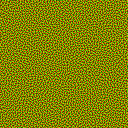

In [36]:
from PIL import Image

path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx0of8_0.png"

noisemap_a = Image.open(path)
display(noisemap_a)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from PIL import Image
from typing import Tuple

def normalize_offsets(image, *, center: float = 127.5) -> np.ndarray:
    offsets = np.asarray(image)[..., :2].astype(np.float32)
    return (offsets - center) / center

def scatter_index_colored(offsets: np.ndarray, *, cmap: str = "viridis", point_size: float = 3.0, alpha: float = 0.6):
    height, width, _ = offsets.shape
    dx = offsets[..., 0].ravel()
    dy = offsets[..., 1].ravel()

    total_span = max(height + width - 2, 1)
    rows, cols = np.indices((height, width), dtype=np.float32)
    colors = ((rows + cols) / total_span).ravel()

    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(dx, dy, c=colors, cmap=cmap, s=point_size, alpha=alpha)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Noise Offsets with Index Gradient")
    fig.colorbar(scatter, ax=ax, label="Mean normalized index")
    return fig, ax

def sort_offsets_by_target(offsets: np.ndarray, target: Tuple[float, float] = (1.0, 1.0)) -> np.ndarray:
    height, width, _ = offsets.shape
    flat = offsets.reshape(-1, 2)
    target_vec = np.asarray(target, dtype=np.float32)

    distance_order = np.argsort(np.linalg.norm(flat - target_vec, axis=1))

    rows, cols = np.indices((height, width))
    rows = rows.ravel()
    cols = cols.ravel()
    position_order = np.lexsort((cols, rows + cols))

    reordered = np.empty_like(flat)
    reordered[position_order] = flat[distance_order]
    return reordered.reshape(height, width, 2)

def offsets_to_image(offsets: np.ndarray):
    uint8_data = ((offsets + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    rgb = np.zeros((*offsets.shape[:2], 3), dtype=np.uint8)
    rgb[..., :2] = uint8_data
    return Image.fromarray(rgb, mode="RGB")

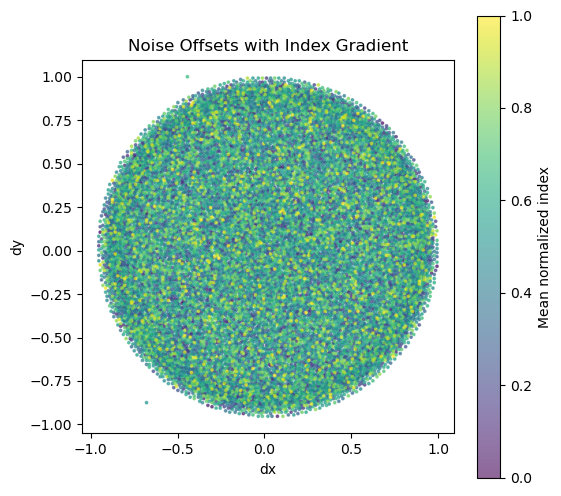

In [38]:
offsets_a = normalize_offsets(noisemap_a)
scatter_index_colored(offsets_a)
plt.show()

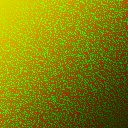

In [39]:
sorted_offsets_a = sort_offsets_by_target(offsets_a)
sorted_image_a = offsets_to_image(sorted_offsets_a)
display(sorted_image_a)

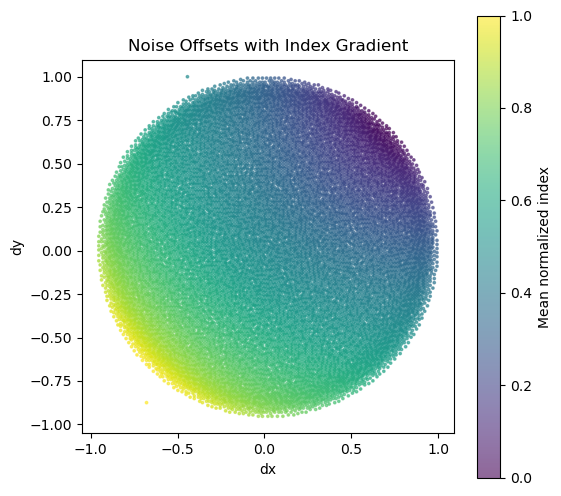

In [40]:
scatter_index_colored(sorted_offsets_a)
plt.show()

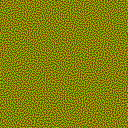

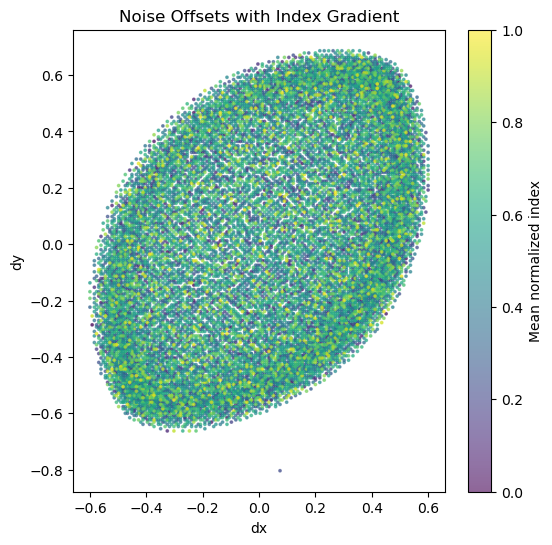

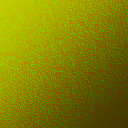

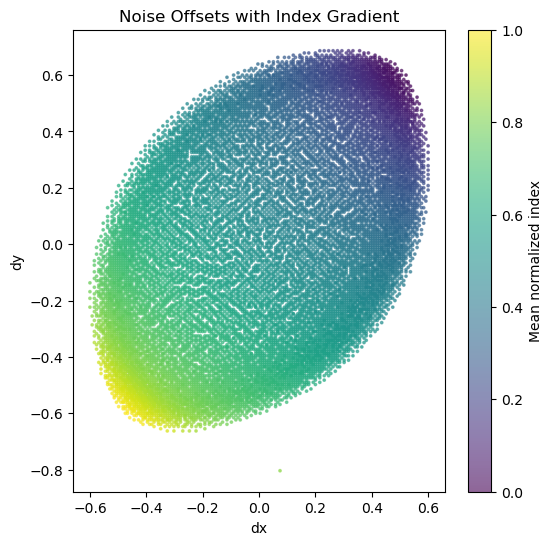

In [41]:
bokeh_map_path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx6of8_0.png"

noisemap_b = Image.open(bokeh_map_path)
display(noisemap_b)

offsets_b = normalize_offsets(noisemap_b)
scatter_index_colored(offsets_b)
plt.show()

sorted_offsets_b = sort_offsets_by_target(offsets_b)
sorted_image_b = offsets_to_image(sorted_offsets_b)
display(sorted_image_b)

scatter_index_colored(sorted_offsets_b)
plt.show()

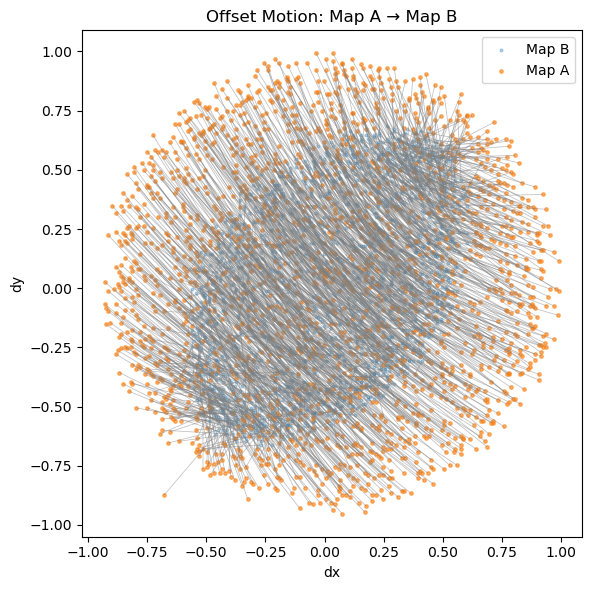

In [42]:
flat_a = sorted_offsets_a.reshape(-1, 2)
flat_b = sorted_offsets_b.reshape(-1, 2)

sample_count = 2000
if flat_a.shape[0] > sample_count:
    idx = np.linspace(0, flat_a.shape[0] - 1, sample_count, dtype=int)
    sample_a = flat_a[idx]
    sample_b = flat_b[idx]
else:
    sample_a = flat_a
    sample_b = flat_b

dx = sample_a[:, 0]
dy = sample_a[:, 1]
du = sample_b[:, 0] - sample_a[:, 0]
dv = sample_b[:, 1] - sample_a[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(sample_b[:, 0], sample_b[:, 1], s=4, alpha=0.3, color="tab:blue", label="Map B")
plt.scatter(dx, dy, s=6, alpha=0.6, color="tab:orange", label="Map A")
plt.quiver(dx, dy, du, dv, angles="xy", scale_units="xy", scale=1, width=0.0015, color="gray", alpha=0.5)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("dx")
plt.ylabel("dy")
plt.title("Offset Motion: Map A → Map B")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [43]:
blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description="Blend")

@widgets.interact(t=blend_slider)
def visualize_offset_interpolation(t: float = 0.0):
    interp = sample_a + t * (sample_b - sample_a)
    step = max(1, interp.shape[0] // 800)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(sample_b[:, 0], sample_b[:, 1], s=4, alpha=0.25, color="tab:blue", label="Map B")
    ax.scatter(sample_a[:, 0], sample_a[:, 1], s=4, alpha=0.25, color="tab:orange", label="Map A")
    ax.scatter(interp[:, 0], interp[:, 1], s=8, alpha=0.7, color="tab:green", label="Blend")
    delta = interp - sample_a
    ax.quiver(sample_a[::step, 0], sample_a[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Interpolated Offsets (t = {:.2f})".format(t))
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='Blend', max=1.0, step=0.02), Output()), _dom_classes…

# Optimal Transport (OMT)

In [44]:
def load_gray(path: Path, resolution: Optional[Tuple[int, int]] = None, resample: int = Image.BILINEAR) -> np.ndarray:
    with Image.open(path) as img:
        if resolution is not None:
            target_height, target_width = resolution
            if img.size != (target_width, target_height):
                img = img.resize((target_width, target_height), resample=resample)
        data = np.asarray(img, dtype=np.float64)
    return data

In [ ]:
import torch
from matplotlib import colors

def refine_density_with_adam(
    source_coords_np: np.ndarray,
    source_density_np: np.ndarray,
    target_density_np: np.ndarray,
    *,
    init_field_np: np.ndarray | None = None,
    previous_distortion: np.ndarray | None = None,
    mid_density_np: np.ndarray | None = None,
    mid_weight: float = 1.0,
    smoothness_weight: float = 0.0,
    magnitude_weight: float = 0.0,
    lr: float = 1e-3,
    max_iters: int = 10_000,
    loss_fn = torch.nn.functional.l1_loss,
    log_interval: int = 200,
    device: torch.device | None = None,
 ) -> dict:
    """Refine a displacement field so pushed-forward source density matches target."""
    source_coords_np = np.asarray(source_coords_np, dtype=np.float32)
    source_density_np = np.asarray(source_density_np, dtype=np.float32)
    target_density_np = np.asarray(target_density_np, dtype=np.float32)
    height, width, _ = source_coords_np.shape
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    smoothness_weight = float(smoothness_weight)
    magnitude_weight = float(magnitude_weight)
    print("Using device:", device)

    coords_t = torch.from_numpy(source_coords_np).to(device=device)
    source_mass_t = torch.from_numpy(source_density_np).to(device=device)
    target_mass_t = torch.from_numpy(target_density_np).to(device=device)
    base_field = (
        torch.from_numpy(np.asarray(init_field_np, dtype=np.float32)).to(device=device)
        if init_field_np is not None
        else torch.zeros_like(coords_t)
    )
    field = torch.nn.Parameter(base_field.clone())
    optimizer = torch.optim.Adam([field], lr=lr)
    loss_history: list[float] = []
    primary_loss_history: list[float] = []
    mid_loss_history: list[float] = []
    smooth_loss_history: list[float] = []
    magnitude_loss_history: list[float] = []

    if mid_density_np is not None:
        mid_density_np = np.asarray(mid_density_np, dtype=np.float32)
        if mid_density_np.shape != (height, width):
            raise ValueError("Intermediate density must match the source grid shape")
        mid_target_t = torch.from_numpy(mid_density_np).to(device=device)
    else:
        mid_target_t = None

    def push_forward_density(field_tensor: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
        distorted = coords_t + field_tensor * scale
        dest_x = ((distorted[..., 1] + 1.0) * 0.5 * (width - 1)).clamp(0.0, width - 1.0)
        dest_y = ((distorted[..., 0] + 1.0) * 0.5 * (height - 1)).clamp(0.0, height - 1.0)

        x0 = dest_x.floor().long()
        y0 = dest_y.floor().long()
        x1 = torch.clamp(x0 + 1, max=width - 1)
        y1 = torch.clamp(y0 + 1, max=height - 1)

        wx = dest_x - x0.to(dest_x.dtype)
        wy = dest_y - y0.to(dest_y.dtype)

        w00 = (1.0 - wx) * (1.0 - wy)
        w10 = wx * (1.0 - wy)
        w01 = (1.0 - wx) * wy
        w11 = wx * wy

        flat_mass = source_mass_t.reshape(-1)
        expected = torch.zeros_like(flat_mass)

        flat_idx00 = (y0 * width + x0).reshape(-1)
        flat_idx10 = (y0 * width + x1).reshape(-1)
        flat_idx01 = (y1 * width + x0).reshape(-1)
        flat_idx11 = (y1 * width + x1).reshape(-1)

        expected.scatter_add_(0, flat_idx00, flat_mass * w00.reshape(-1))
        expected.scatter_add_(0, flat_idx10, flat_mass * w10.reshape(-1))
        expected.scatter_add_(0, flat_idx01, flat_mass * w01.reshape(-1))
        expected.scatter_add_(0, flat_idx11, flat_mass * w11.reshape(-1))

        expected = expected.view(height, width)
        total_mass = expected.sum().clamp_min(1e-12)
        return expected / total_mass

    def smoothness_penalty(field_tensor: torch.Tensor) -> torch.Tensor:
        penalty = torch.zeros((), device=field_tensor.device, dtype=field_tensor.dtype)
        if field_tensor.shape[0] > 1:
            diff_y = field_tensor[1:, :, :] - field_tensor[:-1, :, :]
            penalty = penalty + diff_y.pow(2).mean()
        if field_tensor.shape[1] > 1:
            diff_x = field_tensor[:, 1:, :] - field_tensor[:, :-1, :]
            penalty = penalty + diff_x.pow(2).mean()
        return penalty

    def magnitude_penalty(field_tensor: torch.Tensor) -> torch.Tensor:
        return field_tensor.pow(2).sum(dim=-1).mean()

    with torch.no_grad():
        expected_initial_t = push_forward_density(base_field)
        baseline_primary_loss = float(loss_fn(expected_initial_t, target_mass_t))
        expected_mid_initial = None
        baseline_mid_loss = 0.0
        if mid_target_t is not None:
            expected_mid_initial_t = push_forward_density(base_field, scale=0.5)
            baseline_mid_loss = float(loss_fn(expected_mid_initial_t, mid_target_t))
            expected_mid_initial = expected_mid_initial_t.cpu().numpy()
        baseline_total_loss = baseline_primary_loss + (mid_weight * baseline_mid_loss if mid_target_t is not None else 0.0)
        if smoothness_weight > 0.0:
            baseline_total_loss += smoothness_weight * float(smoothness_penalty(base_field).item())
        if magnitude_weight > 0.0:
            baseline_total_loss += magnitude_weight * float(magnitude_penalty(base_field).item())

    for step in range(int(max_iters)):
        optimizer.zero_grad()
        expected_density_t = push_forward_density(field)
        primary_loss = loss_fn(expected_density_t, target_mass_t)
        total_loss = primary_loss
        mid_loss_value = 0.0
        smooth_loss_value = 0.0
        magnitude_loss_value = 0.0
        if mid_target_t is not None:
            expected_mid_density_t = push_forward_density(field, scale=0.5)
            mid_loss = loss_fn(expected_mid_density_t, mid_target_t)
            total_loss = total_loss + mid_weight * mid_loss
            mid_loss_value = float(mid_loss.item())
        if smoothness_weight > 0.0:
            smooth_loss = smoothness_penalty(field)
            total_loss = total_loss + smoothness_weight * smooth_loss
            smooth_loss_value = float(smooth_loss.item())
        if magnitude_weight > 0.0:
            magnitude_loss = magnitude_penalty(field)
            total_loss = total_loss + magnitude_weight * magnitude_loss
            magnitude_loss_value = float(magnitude_loss.item())
        total_loss.backward()
        optimizer.step()
        with torch.no_grad():
            clamped = torch.clamp(coords_t + field.data, min=-1.0, max=1.0)
            field.data.copy_(clamped - coords_t)
        loss_history.append(float(total_loss.item()))
        primary_loss_history.append(float(primary_loss.item()))
        if mid_target_t is not None:
            mid_loss_history.append(mid_loss_value)
        if smoothness_weight > 0.0:
            smooth_loss_history.append(smooth_loss_value)
        if magnitude_weight > 0.0:
            magnitude_loss_history.append(magnitude_loss_value)
        if log_interval and (step == 0 or (step + 1) % log_interval == 0 or step == max_iters - 1):
            components: list[str] = [f"primary {primary_loss.item():.6f}"]
            if mid_target_t is not None:
                components.append(f"mid {mid_loss_value:.6f}")
            if smoothness_weight > 0.0:
                components.append(f"smooth {smooth_loss_value:.6f}")
            if magnitude_weight > 0.0:
                components.append(f"mag {magnitude_loss_value:.6f}")
            joined = ", ".join(components)
            print(f"iter {step + 1:04d} total {total_loss.item():.6f} ({joined})")

    with torch.no_grad():
        expected_final_t = push_forward_density(field)
        expected_final = expected_final_t.cpu().numpy()
        expected_initial = expected_initial_t.cpu().numpy()
        field_final = field.detach().cpu().numpy()
        final_primary_loss = float(loss_fn(expected_final_t, target_mass_t))
        expected_mid_final = None
        final_mid_loss = 0.0
        if mid_target_t is not None and previous_distortion is not None:
            prev_field_t = torch.from_numpy(np.asarray(previous_distortion, dtype=np.float32)).to(device=device)
            if prev_field_t.shape != field.shape:
                raise ValueError("Previous distortion field has incompatible shape")
            interpolated_field = 0.5 * prev_field_t + 0.5 * field
            expected_mid_final_t = push_forward_density(interpolated_field)
            final_mid_loss = float(loss_fn(expected_mid_final_t, mid_target_t))
            expected_mid_final = expected_mid_final_t.cpu().numpy()

    loss_array = np.asarray(loss_history, dtype=np.float64)
    primary_loss_array = np.asarray(primary_loss_history, dtype=np.float64)
    mid_loss_array = (
        np.asarray(mid_loss_history, dtype=np.float64) if mid_loss_history else np.empty((0,), dtype=np.float64)
    )
    smooth_loss_array = (
        np.asarray(smooth_loss_history, dtype=np.float64) if smooth_loss_history else np.empty((0,), dtype=np.float64)
    )
    magnitude_loss_array = (
        np.asarray(magnitude_loss_history, dtype=np.float64) if magnitude_loss_history else np.empty((0,), dtype=np.float64)
    )
    final_total_loss = float(loss_array[-1]) if loss_array.size else baseline_total_loss

    return {
        "expected_initial": expected_initial,
        "expected_final": expected_final,
        "expected_mid_initial": expected_mid_initial,
        "expected_mid_final": expected_mid_final,
        "field": field_final,
        "loss_history": loss_array,
        "primary_loss_history": primary_loss_array,
        "mid_loss_history": mid_loss_array,
        "smooth_loss_history": smooth_loss_array,
        "magnitude_loss_history": magnitude_loss_array,
        "baseline_loss": baseline_total_loss,
        "baseline_primary_loss": baseline_primary_loss,
        "baseline_mid_loss": baseline_mid_loss,
        "final_loss": final_total_loss,
        "final_primary_loss": final_primary_loss,
        "final_mid_loss": final_mid_loss,
        "mid_weight": mid_weight,
        "smoothness_weight": smoothness_weight,
        "magnitude_weight": magnitude_weight,
    }

def plot_density_panels(panels: list[tuple[str, np.ndarray]]):
    if not panels:
        return
    norm = colors.Normalize(
        vmin=min(panel.min() for _, panel in panels),
        vmax=max(panel.max() for _, panel in panels),
    )
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4), sharex=True, sharey=True)
    if len(panels) == 1:
        axes = [axes]
    for idx, (ax, (title, data)) in enumerate(zip(axes, panels)):
        im = ax.imshow(
            data,
            origin="lower",
            extent=[-1.0, 1.0, -1.0, 1.0],
            cmap="magma",
            norm=norm,
        )
        ax.set_title(title)
        ax.set_xlabel("x (normalized)")
        ax.set_ylabel("y (normalized)" if idx == 0 else "")
    fig.tight_layout(rect=[0.0, 0.0, 0.92, 1.0])
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)
    plt.show()

def plot_loss_curves(curves: dict[str, np.ndarray], *, title: str = "Loss curves", ylabel: str = "loss"):
    if not curves:
        return
    plt.figure(figsize=(6, 3))
    for label, history in curves.items():
        if history.size:
            plt.plot(history, label=label)
    plt.xlabel("iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    if any(history.size for history in curves.values()):
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_component_stack(result: dict, *, title: str):
    total = result["loss_history"]
    if not total.size:
        return
    iterations = np.arange(total.size)
    stacks: list[np.ndarray] = []
    labels: list[str] = []
    stacks.append(result["primary_loss_history"])
    labels.append("primary")
    if result["mid_loss_history"].size:
        stacks.append(result["mid_loss_history"] * result["mid_weight"])
        labels.append(f"mid × {result['mid_weight']:.3g}")
    if result["smooth_loss_history"].size:
        stacks.append(result["smooth_loss_history"] * result["smoothness_weight"])
        labels.append(f"smooth × {result['smoothness_weight']:.3g}")
    if result["magnitude_loss_history"].size:
        stacks.append(result["magnitude_loss_history"] * result["magnitude_weight"])
        labels.append(f"mag × {result['magnitude_weight']:.3g}")
    plt.figure(figsize=(6, 3))
    plt.stackplot(iterations, *stacks, labels=labels, alpha=0.6)
    plt.xlabel("iteration")
    plt.ylabel("loss contribution")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

def report_losses(label: str, result: dict):
    print(
        f"{label} total baseline {result['baseline_loss']:.6f} → "
        f"final {result['final_loss']:.6f}"
    )
    if result["baseline_mid_loss"] or result["final_mid_loss"]:
        print(
            f"{label} midpoint baseline {result['baseline_mid_loss']:.6f} → "
            f"final {result['final_mid_loss']:.6f}"
        )
    if result["smooth_loss_history"].size:
        print(
            f"{label} smoothness weight {result['smoothness_weight']:.3e} "
            f"last smooth penalty {result['smooth_loss_history'][-1]:.6f}"
        )
    if result["magnitude_loss_history"].size:
        print(
            f"{label} magnitude weight {result['magnitude_weight']:.3e} "
            f"last magnitude penalty {result['magnitude_loss_history'][-1]:.6f}"
        )

## Generalized case

In [59]:
import numpy as np
import ot
from pathlib import Path
from typing import Optional, Tuple
from PIL import Image


def load_images_and_create_distortion_map(
    pathA: Path,
    pathB: Path,
    output_path: Path,
    *,
    resolution: Optional[Tuple[int, int]] = None,
    resample: int = Image.BICUBIC,
    previous_distortion: Optional[np.ndarray] = None,
    midpoint_path: Optional[Path] = None,
    lr: float = 1e-4,
    max_iters: int = 10_000,
    log_interval: int = 500,
    mid_weight: float = 1.0,
    smoothness_weight: float = 5e-2,
    magnitude_weight: float = 5e-4
 ) -> np.ndarray:
    
    density_a = load_gray(pathA, resolution=resolution, resample=resample)
    density_b = load_gray(pathB, resolution=resolution, resample=resample)

    if density_a.shape != density_b.shape:
        raise ValueError("OT images must share the same resolution")

    density_a = np.clip(density_a, 0.0, None)
    density_b = np.clip(density_b, 0.0, None)

    total_a = density_a.sum()
    total_b = density_b.sum()
    if total_a == 0 or total_b == 0:
        raise ValueError("Encountered an empty density map")

    source_mass = (density_a / total_a).ravel()
    target_mass = (density_b / total_b).ravel()

    height, width = density_a.shape
    unit_y = np.linspace(-1.0, 1.0, height, dtype=np.float64)
    unit_x = np.linspace(-1.0, 1.0, width, dtype=np.float64)
    unit_mesh_y, unit_mesh_x = np.meshgrid(unit_y, unit_x, indexing="ij")
    source_coords = np.stack((unit_mesh_y, unit_mesh_x), axis=-1)
    unit_positions = source_coords.reshape(-1, 2)

    solution = ot.solve_sample(
        unit_positions,
        unit_positions,
        source_mass,
        target_mass,
        unbalanced=10,
    )
    plan = solution.plan

    plan_row_mass = plan.sum(axis=1)
    expected_targets = unit_positions.copy()
    mass_mask = plan_row_mass > 1e-9
    np.divide(plan @ unit_positions, plan_row_mass[:, None], out=expected_targets, where=mass_mask[:, None])

    omt_vectors = (expected_targets - unit_positions).reshape(height, width, 2)

    source_grid = source_mass.reshape(height, width)
    target_grid = target_mass.reshape(height, width)

    refine_kwargs = dict(
        source_coords_np=source_coords,
        source_density_np=source_grid,
        target_density_np=target_grid,
        init_field_np=omt_vectors,
        lr=lr,
        max_iters=max_iters,
        log_interval=log_interval,
        smoothness_weight=smoothness_weight,
        magnitude_weight=magnitude_weight
    )

    if midpoint_path is not None:

        density_mid = load_gray(midpoint_path, resolution=resolution, resample=resample)
        if density_mid.shape != (height, width):
            raise ValueError("Midpoint density must match the requested resolution")
        density_mid = np.clip(density_mid, 0.0, None)
        total_mid = density_mid.sum()
        if total_mid == 0:
            raise ValueError("Encountered an empty midpoint density map")
        midpoint_grid = (density_mid / total_mid).reshape(height, width)

        # add midpoint arguments
        refine_kwargs["mid_density_np"] = midpoint_grid
        refine_kwargs["mid_weight"] = mid_weight
        refine_kwargs["previous_distortion"] = previous_distortion

    refinement = refine_density_with_adam(**refine_kwargs)

    omt_vectors_refined = refinement["field"]
    expected_density_initial = refinement["expected_initial"]
    expected_density_refined = refinement["expected_final"]
    loss_history = refinement["loss_history"]
    baseline_loss = refinement["baseline_loss"]
    final_loss = refinement["final_loss"]

    if loss_history.size:
        print(
            f"Adam refinement baseline {baseline_loss:.6f} → final {final_loss:.6f} "
            f"after {loss_history.size} iterations"
        )
    else:
        print(f"Adam refinement baseline {baseline_loss:.6f} (no optimization steps recorded)")

    pair_label = f"({pathA.name} -> {pathB.name})"
    plot_density_panels([
        ("Source density", source_grid),
        ("Target density", target_grid),
        ("OMT initial", expected_density_initial),
        ("OMT refined", expected_density_refined),
    ])
    if loss_history.size:
        plot_loss_component_stack(refinement, title=f"{pair_label} loss breakdown")
    elif refinement["smooth_loss_history"].size:
        plot_loss_curves({"smooth": refinement["smooth_loss_history"]}, title=f"{pair_label} smooth penalty", ylabel="smooth penalty")

    if midpoint_path is not None and refinement["expected_mid_initial"] is not None:
        plot_density_panels([
            ("Mid target", midpoint_grid),
            ("OMT mid initial", refinement["expected_mid_initial"]),
            ("OMT mid refined", refinement["expected_mid_final"]),
        ])
        if not loss_history.size and refinement["mid_loss_history"].size:
            plot_loss_curves({"mid": refinement["mid_loss_history"]}, title=f"{pair_label} mid loss", ylabel="mid loss")

    distortion_map = source_coords + omt_vectors_refined
    distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
    uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    distortion_rgb[..., :2] = uint8_data

    Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
    print(f"Saved distortion map to {output_path}")

    global source_coords_unit
    source_coords_unit = source_coords

    print("type of distortion_map:", type(distortion_map))

    return distortion_map

### Load all bokeh shapes and create distortion maps


=== Distortion map 00_00 ===


C:\Users\ckobalt\AppData\Local\anaconda3\Lib\site-packages\ot\backend.py:1424: RuntimeWarning: invalid value encountered in divide
  value = np.sum(p * np.log(p / q + eps))


Using device: cpu
iter 0001 total 0.000166 (primary 0.000144, smooth 0.000435, mag 0.000928)
iter 0500 total 0.000026 (primary 0.000023, smooth 0.000052, mag 0.000385)
iter 1000 total 0.000003 (primary 0.000002, smooth 0.000020, mag 0.000132)
iter 1500 total 0.000001 (primary 0.000001, smooth 0.000005, mag 0.000031)
iter 2000 total 0.000001 (primary 0.000000, smooth 0.000003, mag 0.000013)
iter 2500 total 0.000001 (primary 0.000000, smooth 0.000002, mag 0.000009)
iter 3000 total 0.000001 (primary 0.000000, smooth 0.000001, mag 0.000007)
iter 3500 total 0.000000 (primary 0.000000, smooth 0.000001, mag 0.000006)
iter 4000 total 0.000000 (primary 0.000000, smooth 0.000001, mag 0.000005)
iter 4500 total 0.000000 (primary 0.000000, smooth 0.000001, mag 0.000004)
iter 5000 total 0.000000 (primary 0.000000, smooth 0.000001, mag 0.000004)
iter 5500 total 0.000000 (primary 0.000000, smooth 0.000001, mag 0.000003)
iter 6000 total 0.000000 (primary 0.000000, smooth 0.000001, mag 0.000003)
iter 65

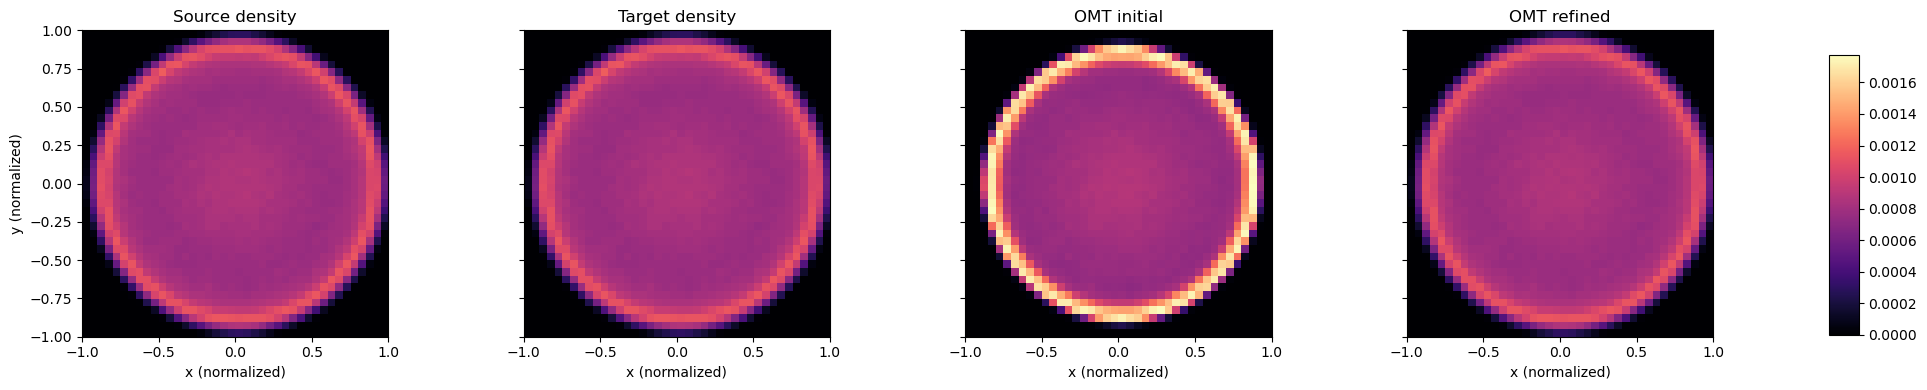

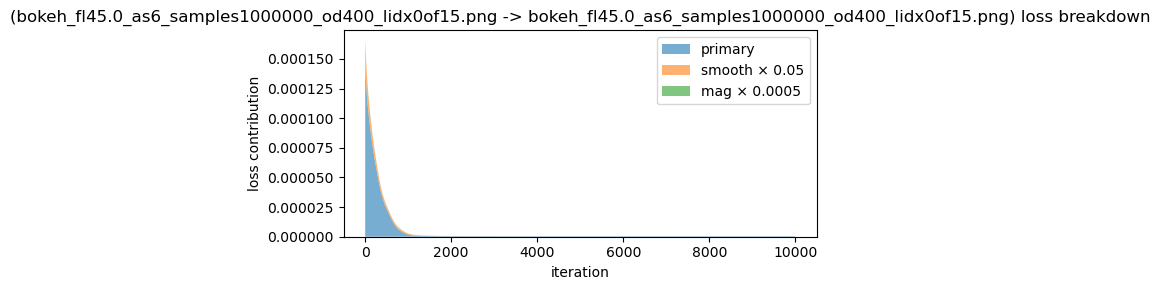

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_00_00.png
type of distortion_map: <class 'numpy.ndarray'>

=== Distortion map 00_02 ===
Using device: cpu
iter 0001 total 0.000271 (primary 0.000147, mid 0.000082, smooth 0.000780, mag 0.004494)
iter 0500 total 0.000057 (primary 0.000020, mid 0.000029, smooth 0.000138, mag 0.003574)
iter 1000 total 0.000036 (primary 0.000005, mid 0.000026, smooth 0.000056, mag 0.003713)
iter 1500 total 0.000034 (primary 0.000004, mid 0.000026, smooth 0.000051, mag 0.003815)
iter 2000 total 0.000033 (primary 0.000003, mid 0.000026, smooth 0.000051, mag 0.003828)
iter 2500 total 0.000033 (primary 0.000003, mid 0.000025, smooth 0.000052, mag 0.003832)
iter 3000 total 0.000033 (primary 0.000003, mid 0.000025, smooth 0.000052, mag 0.003834)
iter 3500 total 0.000033 (primary 0.000003, mid 0.000025, smooth 0.000053, mag 0.003836)
iter 4000 total 0.000033 (primary 0.000003, mid 0.0

C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_51980\896128733.py:172: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  expected_mid_final_t = push_forward_density(np.add(0.5 * previous_distortion, 0.5 * field))


RuntimeError: scatter(): Expected self.dtype to be equal to src.dtype

In [60]:
output_folder = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/distortion_maps")
desired_resolution = (40, 40) # todo: increase to 70x70

all_paths = {
    idx: Path(
        f"C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/"
        f"bokeh_fl45.0_as6_samples1000000_od400_lidx{idx}of15.png"
    )
    for idx in range(14)
}
midpoint_paths = {idx: path for idx, path in all_paths.items() if idx % 2 == 1}

previous_distortion = None
start_idx = 0
for end_idx in range(0, 14, 2):
    midpoint_idx = end_idx - 1
    midpoint_path = midpoint_paths.get(midpoint_idx)
    label = f"{start_idx:02d}_{end_idx:02d}"
    print(f"\n=== Distortion map {label} ===")
    previous_distortion = load_images_and_create_distortion_map(
        all_paths[start_idx],
        all_paths[end_idx],
        output_folder / f"distortion_map_{label}.png",
        resolution=desired_resolution,
        previous_distortion=previous_distortion,
        midpoint_path=midpoint_path,
    )

### Transition noise from one bokeh shape to another

In [61]:
from pathlib import Path

import numpy as np
from PIL import Image

distortion_dir = Path(output_folder)
distortion_maps = sorted(distortion_dir.glob("distortion_map_*.png"))
if not distortion_maps:
    raise FileNotFoundError(f"No distortion maps found in {distortion_dir}")

def load_displacement(path):
    data = np.asarray(Image.open(path), dtype=np.float32)[..., :2]
    dest = (data / 127.5) - 1.0
    dy = dest[..., 1] - source_coords_unit[..., 0]
    dx = dest[..., 0] - source_coords_unit[..., 1]
    return np.stack((dy, dx), axis=-1)

sequence_fields = [load_displacement(path) for path in distortion_maps]
field_height, field_width = sequence_fields[0].shape[:2]

def displacement_at(field, points):
    pts = points.reshape(-1, 2)
    norm = np.clip((pts - value_min) / (value_max - value_min), 0.0, 0.999999)
    y_idx = (norm[:, 0] * (field_height - 1)).astype(int)
    x_idx = (norm[:, 1] * (field_width - 1)).astype(int)
    return field[y_idx, x_idx]

def apply_field(points, field, amount=1.0):
    move = displacement_at(field, points)
    return np.clip(points + amount * move, value_min, value_max)

def move_through_sequence(points, fields, t):
    if not fields:
        return points, 0, 0.0
    total = len(fields)
    progress = np.clip(t, 0.0, 1.0) * total
    segment = min(int(progress), total - 1)
    local = progress - segment
    carried = points.copy()
    for field in fields[:segment]:
        carried = apply_field(carried, field)
    carried = apply_field(carried, fields[segment], amount=local)
    return carried, segment, local

stage_samples = [samples_a]
current = samples_a
for field in sequence_fields:
    current = apply_field(current, field)
    stage_samples.append(current)

segment_titles = [f"Map {i} → {i + 1}" for i in range(len(sequence_fields))]

NameError: name 'samples_a' is not defined

In [ ]:
def render_sequence_frame(t: float):
    interpolated, segment, local_t = move_through_sequence(samples_a, sequence_fields, t)
    start = stage_samples[segment]
    target = stage_samples[min(segment + 1, len(stage_samples) - 1)]
    step = max(1, interpolated.shape[0] // 800)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(start[:, 0], start[:, 1], s=6, alpha=0.35, color="tab:orange", label=f"Start #{segment}")
    ax.scatter(target[:, 0], target[:, 1], s=6, alpha=0.35, color="tab:blue", label=f"Target #{segment + 1}")
    ax.scatter(interpolated[:, 0], interpolated[:, 1], s=8, alpha=0.7, color="tab:green", label="Interpolated")
    delta = interpolated - start
    ax.quiver(start[::step, 0], start[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.45)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title(f"{segment_titles[segment]} — global t={t:.3f}, local={local_t:.2f}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return fig

blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description="Sequence Blend")

@widgets.interact(t=blend_slider)
def visualize_sequence_interpolation(t: float = 0.0):
    fig = render_sequence_frame(t)
    display(fig)
    plt.close(fig)

interactive(children=(FloatSlider(value=0.0, description='Sequence Blend', max=1.0, step=0.01), Output()), _do…